# Neural Network creation for Pump-valves block data

***

**Author:** Juan M. Montes-Sánchez

**GitHub:** https://github.com/juamonsan

***

In this notebook you will find a step by step guide where you will:
- Load data taken with FP-SNS-DATALOG1 on a STEVAL-MKSBOX1V1FP-SNS-DATALOG and pre-processed as .csv files with "Dataset preparation" notebook from this same project
- Split the data into train, evaluation and test
- Generate and train a Neural Network capable of classifing lectures from the sensors
- Generating plots and metrics related to the data or the Neural Network

## Requirements

You **MUST** have:
- Data in .csv and with a proper folder structure created with "Dataset preparation" notebook from this same project

Optional requirements include:
- CUDA compatible Nvidia GPU

## Previous steps

### Neural Network environment: Importing Keras/Tensorflow

Import tensorflow and check if we have GPUs availables. If so, it means a GPU is ready to be used for tensorflow training.

In [1]:
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.layers import LSTM, GRU, Dropout
from tensorflow.keras.optimizers import Adam, SGD

from tensorflow.keras.utils import to_categorical

import sys

print("Python version {}.{}".format(sys.version_info.major, sys.version_info.minor))

print("Tensorflow version " + tf.__version__)

Python version 3.7
Tensorflow version 2.1.0


In [2]:
from tensorflow.python.client import device_lib

num_GPUs=len(tf.config.experimental.list_physical_devices('GPU'))

tf.config.list_physical_devices('GPU')

device_lib.list_local_devices()

tf.test.is_built_with_cuda()

tf.debugging.set_log_device_placement(True)


if(num_GPUs>0):
    print("Your system has {} GPUs availables".format(num_GPUs))
else:
    print("No GPUs available")    


Your system has 1 GPUs availables


---
If we have a Nvidia GPU with drivers and CUDA properly installed we can also get some extra information: GPU model, driver and CUDA versions, activity...

In [3]:
# GPU count and name
!nvidia-smi -L
# GPU activity
!nvidia-smi

GPU 0: NVIDIA GeForce GTX 1650 (UUID: GPU-235cadad-b6ee-9e16-4bcd-63bcc7b79e19)
Fri Jun 30 12:16:15 2023       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.98                 Driver Version: 535.98       CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                     TCC/WDDM  | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  | 00000000:01:00.0 Off |                  N/A |
| N/A   46C    P8               3W /  50W |    158MiB /  4096MiB |      0%      Default |
|                                         |                      |            

---
### Other imports

In [4]:
# More imports
import matplotlib.pyplot as plt #for plotting raw data
import os #for system folders and files management
import pathlib #for system folders and files management
import pandas as pd #for Dataframe handling

from IPython.display import display # for folder selection dialog
from ipyfilechooser import FileChooser # for folder selection dialog

import numpy as np
import math
import csv

from IPython.display import Audio #for WAV generation

# End

In [5]:
# Make numpy values easier to read.
np.set_printoptions(precision=3, suppress=True)

### Definitions

In [6]:
# Dando la ruta del fichero CSV, muestra una grafica de los datos
def plot_record(file_path, xName, yName):
    data = pd.read_csv(file_path, sep=',')
    data = data.to_numpy()
    print("Shape of the data is: {}".format(np.shape(data)))
    #plt.plot(data[:,0], data[:,1], #if we have a timestamp at column 0
    #         data[:,0], data[:,2],
    #         data[:,0], data[:,3])
    plt.plot(range(np.shape(data)[0]), data[:,0],
             range(np.shape(data)[0]), data[:,1],
             range(np.shape(data)[0]), data[:,2])
    plt.xlabel(xName)
    plt.ylabel(yName)
    #plt.xlim((0, 200))
    #plt.ylim((-1500, 1500))

## Loading data

### Loading from CSV



Select data folder and extract data size from the content of the files. We are going to consider the data is already in the desired format.

In [7]:
#Select sensor csv folder:

# Create and display a FileChooser widget
fc = FileChooser('./')
fc.show_only_dirs=True
print("--------------------------------\nSELECT TRAIN DATA SENSOR FOLDER\n--------------------------------")
display(fc)
print("--------------------------------\n")

--------------------------------
SELECT TRAIN DATA SENSOR FOLDER
--------------------------------


FileChooser(path='D:\GIT\STEVAL-MKSBOX1V1_Dataset_creator', filename='', title='', show_hidden=False, select_d…

--------------------------------



Number of samples: 1036
Sample size: 800
Number of features: 3
-----------------------
Plot example for first file:
-----------------------
The class for this file is 2
Shape of the data is: (799, 3)


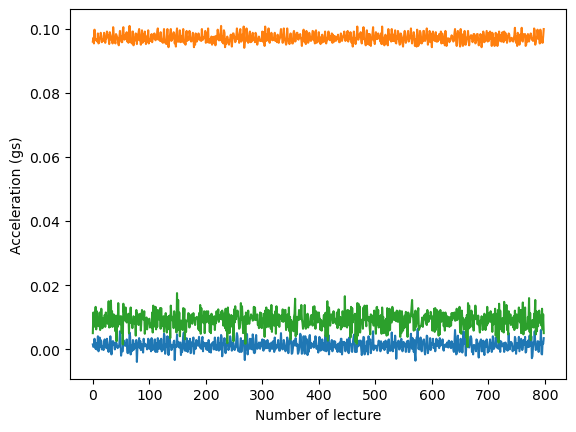

In [83]:
if fc.selected_path==None:
    csv_folder_path="TEST_DATA\\expData\\STBOX_00001_Windows" #Select desired path
    sensor_folder="ACC_LIS3DHH_1100Hz" #Select desired sensor folder
    full_path=os.path.join(csv_folder_path,sensor_folder)
else:
    full_path = fc.selected_path

Current_file_path = os.path.join(full_path,os.listdir(full_path)[0])

Current_file = open(Current_file_path) # Open first file for counting rows

num_samples= len(os.listdir(full_path)) #number of .csv files in total
tam_samples= len(Current_file.readlines())#number of lectures in a window sample (rows in each .csv)
num_features = 3 #axis number (3 for accel) TODO: read column number from the file

print("Number of samples: {}\nSample size: {}\nNumber of features: {}".format(num_samples,tam_samples,num_features))
print("-----------------------\nPlot example for first file:\n-----------------------")

file_class=int(Current_file_path[-6:-4])-1 # Class is in the filename, at the end, just before file extension
print("The class for this file is {}".format(file_class))

plot_record(Current_file_path, 'Number of lecture', 'Acceleration (gs)')

Current_file.close() # Close file

Using the variables from above cell, we create two training numpy arrays for feeding the NN: one contains the data (trainX) and the other the desired outputs in one hot format (trainY)

In [64]:
DataX=np.empty([num_samples, tam_samples, num_features]) # Empty numpy array we will fill with data from .csv files
DataY=np.empty([num_samples])

for i in range (num_samples):
    Current_file_path = os.path.join(full_path,os.listdir(full_path)[i])
    Current_CSV=np.genfromtxt (Current_file_path, delimiter=",")
    DataX[i]=Current_CSV
    
    file_class=int(Current_file_path[-6:-4])
    DataY[i]=file_class-1 #first class is class 1, but now we start from 0
    #print("{} (Class {})".format(Current_file_path,file_class))
#    if file_class == 1:
#        DataY[i]='001'
#    elif file_class == 2:
#        DataY[i]='010'
#    elif file_class == 3:
#        DataY[i]='100'
#    else:
#        print("ERROR")
#        DataY[i]='000'

DataY = to_categorical(DataY)        
print("The shape of DataX array is: {}".format(np.shape(DataX))) # We check if the shape is correct
print("The shape of DataY array is: {}".format(np.shape(DataY)))    
    

The shape of DataX array is: (1036, 800, 3)
The shape of DataY array is: (1036, 3)


#### Split the data

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(DataX, DataY, test_size=0.3, random_state=100, stratify=DataY)
print("X_train shape: {} || X_test shape: {}".format(np.shape(X_train), np.shape(X_test))) # We check if the shape is correct
print("y_train shape: {} || y_test shape: {}".format(np.shape(y_train), np.shape(y_test)))

X_train shape: (725, 800, 3) || X_test shape: (311, 800, 3)
y_train shape: (725, 3) || y_test shape: (311, 3)


### Network definition

In [66]:
#Copiado de notebook de Curro (definiciones de distintas RNN):

def create_1layer_lstm_model(nodes,drp,input_shape):
    
    #input_shape = (None, 550, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(LSTM((nodes)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model


def create_1layer_gru_model(nodes,drp,input_shape):
    
    #input_shape = (None, 550, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(GRU((nodes)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model


def create_2layer_lstm_model(nodes_1stl,nodes_2ndl,drp,input_shape):
    
    #input_shape = (None, 550, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(LSTM((nodes_1stl), return_sequences=True))
    rnn_model.add(Dropout(drp))
    rnn_model.add(LSTM((nodes_2ndl)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model


def create_2layer_gru_model(nodes_1stl,nodes_2ndl,drp,input_shape):
    
    #input_shape = (None, 550, 3)

    rnn_model = Sequential()

    rnn_model.add(BatchNormalization(batch_input_shape = input_shape))
    rnn_model.add(GRU((nodes_1stl), return_sequences=True))
    rnn_model.add(Dropout(drp))
    rnn_model.add(GRU((nodes_2ndl)))
    rnn_model.add(Dropout(drp))
    rnn_model.add(Dense(3, activation='softmax'))
    
    return rnn_model

#### NN training


In [87]:
#Create

nodes_1 = 32
nodes_2 = 16
drp = 0.3
input_shape=(None,tam_samples, num_features)

#model_lstm_2l = create_2layer_lstm_model(nodes_1,nodes_2,drp,input_shape)
model_lstm_2l = create_1layer_gru_model(nodes_1,drp,input_shape)
model_lstm_2l.summary()

Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
batch_normalization_4 (Batch (None, 800, 3)            12        
_________________________________________________________________
gru_4 (GRU)                  (None, 32)                3552      
_________________________________________________________________
dropout_8 (Dropout)          (None, 32)                0         
_________________________________________________________________
dense_4 (Dense)              (None, 3)                 99        
Total params: 3,663
Trainable params: 3,657
Non-trainable params: 6
_________________________________________________________________


In [88]:
#Compile

opt = tf.keras.optimizers.Adam(learning_rate=0.002)

model_lstm_2l.compile(loss='categorical_crossentropy',
        optimizer=opt,
        metrics=["accuracy"])

In [89]:
#Train

epochs = 500
batch_size = 32

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.h5", save_best_only=True, monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=20, min_lr=0.0001
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, verbose=1, start_from_epoch=50),
]


#model_lstm_2l.fit(X_train, y_train, batch_size = batch_size,epochs = epochs, validation_data = (X_test, y_test))
with tf.device('/gpu:0'):
    history = model_lstm_2l.fit(
        X_train,
        y_train,
        batch_size=batch_size,
        epochs=epochs,
        callbacks=callbacks,
        validation_data = (X_test, y_test),
        verbose=1,
    )

Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op Prefet

725/725 [==============================] - 1s 926us/sample - loss: 0.8181 - accuracy: 0.6097 - val_loss: 1.6474 - val_accuracy: 0.3119
Epoch 17/500
725/725 [==============================] - 1s 964us/sample - loss: 0.5414 - accuracy: 0.7283 - val_loss: 2.3819 - val_accuracy: 0.3119
Epoch 18/500
725/725 [==============================] - 1s 924us/sample - loss: 0.4641 - accuracy: 0.7724 - val_loss: 3.3160 - val_accuracy: 0.3119
Epoch 19/500
725/725 [==============================] - 1s 903us/sample - loss: 0.4640 - accuracy: 0.7793 - val_loss: 2.8483 - val_accuracy: 0.3119
Epoch 20/500
725/725 [==============================] - 1s 920us/sample - loss: 0.4258 - accuracy: 0.7986 - val_loss: 3.4522 - val_accuracy: 0.3119
Epoch 21/500
725/725 [==============================] - 1s 952us/sample - loss: 0.6377 - accuracy: 0.6428 - val_loss: 1.0018 - val_accuracy: 0.4727
Epoch 22/500
725/725 [==============================] - 1s 938us/sample - loss: 0.7943 - accuracy: 0.7076 - val_loss: 1.0287 

Epoch 43/500
725/725 [==============================] - 1s 965us/sample - loss: 0.0041 - accuracy: 1.0000 - val_loss: 0.0010 - val_accuracy: 1.0000
Epoch 44/500
725/725 [==============================] - 1s 924us/sample - loss: 0.0135 - accuracy: 0.9931 - val_loss: 0.0017 - val_accuracy: 1.0000
Epoch 45/500
725/725 [==============================] - 1s 911us/sample - loss: 0.0037 - accuracy: 1.0000 - val_loss: 0.0045 - val_accuracy: 1.0000
Epoch 46/500
725/725 [==============================] - 1s 963us/sample - loss: 0.0026 - accuracy: 1.0000 - val_loss: 9.0298e-04 - val_accuracy: 1.0000
Epoch 47/500
725/725 [==============================] - 1s 952us/sample - loss: 0.0018 - accuracy: 1.0000 - val_loss: 7.4604e-04 - val_accuracy: 1.0000
Epoch 48/500
725/725 [==============================] - 1s 966us/sample - loss: 0.0023 - accuracy: 1.0000 - val_loss: 6.0772e-04 - val_accuracy: 1.0000
Epoch 49/500
725/725 [==============================] - 1s 1ms/sample - loss: 0.0018 - accuracy: 1.0

725/725 [==============================] - 1s 924us/sample - loss: 0.0013 - accuracy: 1.0000 - val_loss: 0.0017 - val_accuracy: 1.0000
Epoch 70/500
725/725 [==============================] - 1s 926us/sample - loss: 0.0011 - accuracy: 1.0000 - val_loss: 0.0044 - val_accuracy: 0.9968
Epoch 71/500
725/725 [==============================] - 1s 908us/sample - loss: 9.1649e-04 - accuracy: 1.0000 - val_loss: 0.0070 - val_accuracy: 0.9968
Epoch 72/500
725/725 [==============================] - 1s 924us/sample - loss: 9.4182e-04 - accuracy: 1.0000 - val_loss: 0.0051 - val_accuracy: 0.9968
Epoch 73/500
725/725 [==============================] - 1s 954us/sample - loss: 0.0010 - accuracy: 1.0000 - val_loss: 0.0042 - val_accuracy: 0.9968
Epoch 74/500
725/725 [==============================] - 1s 951us/sample - loss: 8.2145e-04 - accuracy: 1.0000 - val_loss: 0.0045 - val_accuracy: 0.9968
Epoch 75/500
725/725 [==============================] - 1s 964us/sample - loss: 8.5280e-04 - accuracy: 1.0000 - v

Epoch 95/500
725/725 [==============================] - 1s 937us/sample - loss: 0.1312 - accuracy: 0.9683 - val_loss: 0.0963 - val_accuracy: 0.9743
Epoch 96/500
725/725 [==============================] - 1s 937us/sample - loss: 0.1180 - accuracy: 0.9683 - val_loss: 0.0886 - val_accuracy: 0.9807
Epoch 97/500
725/725 [==============================] - 1s 981us/sample - loss: 0.1091 - accuracy: 0.9628 - val_loss: 0.0815 - val_accuracy: 0.9839
Epoch 98/500
725/725 [==============================] - 1s 1ms/sample - loss: 0.1008 - accuracy: 0.9766 - val_loss: 0.0748 - val_accuracy: 0.9839
Epoch 99/500
725/725 [==============================] - 1s 963us/sample - loss: 0.0923 - accuracy: 0.9724 - val_loss: 0.0693 - val_accuracy: 0.9839
Epoch 100/500
725/725 [==============================] - 1s 940us/sample - loss: 0.0891 - accuracy: 0.9807 - val_loss: 0.0637 - val_accuracy: 0.9839
Epoch 101/500
725/725 [==============================] - 1s 1ms/sample - loss: 0.0777 - accuracy: 0.9821 - val_lo

In [90]:
#Model save
best_model_lstm_name = 'best_model_gru_1l.h5'
models_folder = "DATA\\models"
sensor_folder = "ACCEL_2"
sensor_model_folder=os.path.join(models_folder,sensor_folder) 

if not os.path.exists(sensor_model_folder): 
                os.makedirs(sensor_model_folder)


model_lstm_2l.save(os.path.join(sensor_model_folder, best_model_lstm_name))

### Plot model training progression

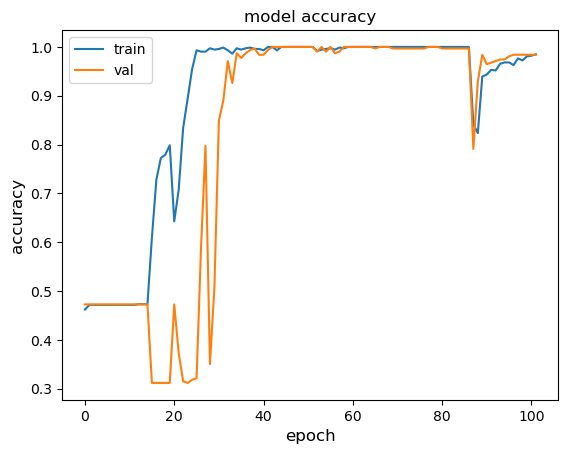

In [91]:
metric = "accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()


## Evaluation

Load test set (holdout, different from validation set)

In [92]:
#Select sensor csv folder:

# Create and display a FileChooser widget
fc_test = FileChooser('./')
fc_test.show_only_dirs=True
print("------------------------------\nSELECT TEST DATA SENSOR FOLDER\n------------------------------")
display(fc_test)
print("------------------------------\n")

------------------------------
SELECT TEST DATA SENSOR FOLDER
------------------------------


FileChooser(path='D:\GIT\STEVAL-MKSBOX1V1_Dataset_creator', filename='', title='', show_hidden=False, select_d…

------------------------------



Number of samples: 614
Sample size: 800
Number of features: 3
-----------------------
Plot example for first file:
-----------------------
The class for this file is 2
Shape of the data is: (799, 3)


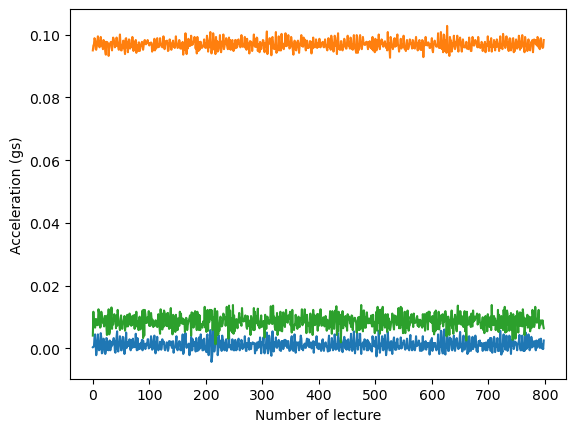

In [93]:
if fc_test.selected_path==None:
    print("No folder specified!! Using validation data as test data...")
    TestDataX=X_test
    TestDataY=y_test
else:
    full_path_test = fc_test.selected_path

    Current_file_path_test = os.path.join(full_path_test,os.listdir(full_path_test)[0])

    Current_file_test = open(Current_file_path_test) # Open first file for counting rows

    num_samples_test= len(os.listdir(full_path_test)) #number of .csv files in total
    tam_samples_test= len(Current_file_test.readlines())#number of lectures in a window sample (rows in each .csv)
    num_features_test = 3 #axis number (3 for accel) TODO: read column number from the file

    print("Number of samples: {}\nSample size: {}\nNumber of features: {}".format(num_samples_test,tam_samples_test,num_features_test))
    print("-----------------------\nPlot example for first file:\n-----------------------")

    file_class_test=int(Current_file_path_test[-6:-4])-1 # Class is in the filename, at the end, just before file extension
    print("The class for this file is {}".format(file_class_test))

    plot_record(Current_file_path_test, 'Number of lecture', 'Acceleration (gs)')

    Current_file_test.close() # Close file
    
    TestDataX=np.empty([num_samples, tam_samples, num_features]) # Empty numpy array we will fill with data from .csv files
    TestDataY=np.empty([num_samples])

    for i in range (num_samples):
        Current_file_path = os.path.join(full_path,os.listdir(full_path)[i])
        Current_CSV=np.genfromtxt (Current_file_path, delimiter=",")
        TestDataX[i]=Current_CSV

        file_class=int(Current_file_path[-6:-4])
        TestDataY[i]=file_class-1 #first class is class 1, but now we start from 0

    TestDataY = to_categorical(TestDataY) 
    

### Predictions made from test (holdout) data

In [41]:
#Select model:

# Create and display a FileChooser widget
fc_model = FileChooser('./')
#fc_test.show_only_dirs=False
print("------------------------------\nSELECT TRAINED MODEL\n------------------------------")
display(fc_model)
print("------------------------------\n")

------------------------------
SELECT TRAINED MODEL
------------------------------


FileChooser(path='D:\GIT\STEVAL-MKSBOX1V1_Dataset_creator', filename='', title='', show_hidden=False, select_d…

------------------------------



In [94]:
if fc_model.selected_path==None:
    print("No model specified!!")
    #model = tf.keras.models.load_model(os.path.join(sensor_model_folder, best_model_lstm_name))
else:
    model = tf.keras.models.load_model(fc_model.selected)
    pred = model.predict(TestDataX)
    print("--------\nDone!")

Executing op VarHandleOp in device /job:localhost/replica:0/task:0/device:GPU:0
Executing op RangeDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op MapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op PrefetchDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op FlatMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op TensorDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op RepeatDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ZipDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ParallelMapDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op ModelDataset in device /job:localhost/replica:0/task:0/device:CPU:0
Executing op __inference_distributed_function_146919 in device /job:localhost/replica:0/task:0/devic

#### To confusion matrix

In [95]:
y_pred = np.argmax(pred, axis = 1)
#y_pred = to_categorical(y_pred) 
y_pred

array([2, 2, 2, ..., 2, 2, 2], dtype=int64)

In [96]:
import sklearn.model_selection
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

In [97]:
p = sklearn.metrics.confusion_matrix(TestDataY.argmax(axis=1), y_pred, labels=[0,1,2])
p

array([[322,   0,   0],
       [  0, 212,  13],
       [  0,   2, 487]], dtype=int64)

In [98]:
p_norm = sklearn.metrics.confusion_matrix(TestDataY.argmax(axis=1), y_pred, labels=[0,1,2], normalize='true')
p_norm

array([[1.   , 0.   , 0.   ],
       [0.   , 0.942, 0.058],
       [0.   , 0.004, 0.996]])

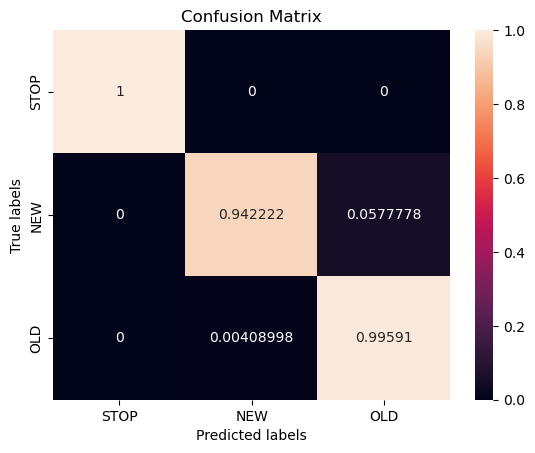

In [99]:
import seaborn as sns

T_lables = ['STOP','NEW','OLD']    

ax= plt.subplot()

sns.heatmap(p_norm, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation

# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels'); 
ax.set_title('Confusion Matrix'); 
ax.xaxis.set_ticklabels(T_lables); ax.yaxis.set_ticklabels(T_lables);

#### More metrics

In [100]:
print(sklearn.metrics.classification_report(TestDataY.argmax(axis=1), y_pred, target_names=['STOP','NEW', 'OLD']))

              precision    recall  f1-score   support

        STOP       1.00      1.00      1.00       322
         NEW       0.99      0.94      0.97       225
         OLD       0.97      1.00      0.98       489

    accuracy                           0.99      1036
   macro avg       0.99      0.98      0.98      1036
weighted avg       0.99      0.99      0.99      1036



---
## Data plot

In [ ]:
# TO DO: METRICS AND PLOT CODE

In [ ]:
# TO DO: METRICS AND PLOT CODE

#### Downsample

Only in case we want to decrease the amount of data (simulating a lower frequency) we can run the next code:

In [ ]:
# para reducir la frecuencia se puede usar! TODO ajustar al ODR
# Slice [start:stop:step], starting from index 5 take every 110th record.-> 1100
df_sliced = df[5::110]
df_sliced.head()